In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

In [ ]:
df = pd.read_csv('spotify_analysis_dataset.csv')
df.columns = df.columns.str.strip() 
print(df.columns)

Index(['track_id', 'track_name', 'artist', 'album', 'release_date',
       'duration_ms', 'popularity', 'danceability', 'energy', 'loudness',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo'],
      dtype='object')


In [3]:
df = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          50 non-null     object 
 1   track_name        50 non-null     object 
 2   artist            50 non-null     object 
 3   album             50 non-null     object 
 4   release_date      50 non-null     object 
 5   duration_ms       50 non-null     int64  
 6   popularity        50 non-null     int64  
 7   danceability      50 non-null     float64
 8   energy            50 non-null     float64
 9   loudness          50 non-null     float64
 10  speechiness       50 non-null     float64
 11  acousticness      50 non-null     float64
 12  instrumentalness  50 non-null     float64
 13  liveness          50 non-null     float64
 14  valence           50 non-null     float64
 15  tempo             50 non-null     float64
dtypes: float64(9), int64(2), object(5)
memory usag

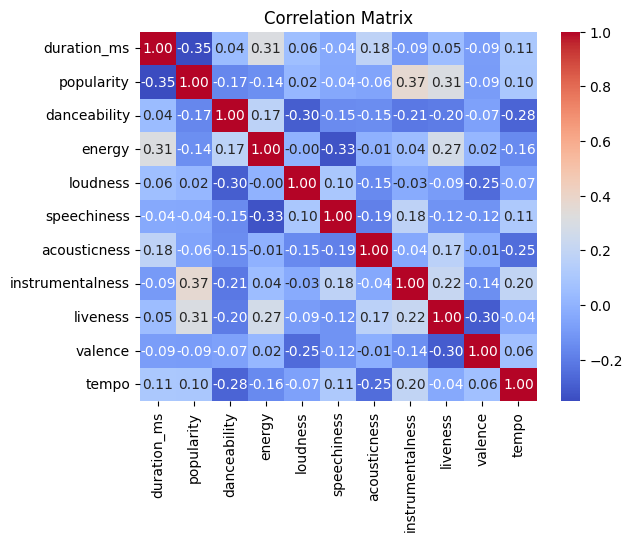

: 

In [ ]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [8]:
features = ['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
X = df[features]

In [9]:
y_lin = df['popularity']

In [10]:
median_pop = df['popularity'].median()
y_log = (df['popularity'] > median_pop).astype(int)

In [11]:
X_train, X_test, y_lin_train, y_lin_test, y_log_train, y_log_test = train_test_split(
    X, y_lin, y_log, test_size=0.2, random_state=42
)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_lin_train)
y_lin_pred = lin_reg.predict(X_test_scaled)

print("--- Linear Regression Metrics ---")
print(f"MSE: {mean_squared_error(y_lin_test, y_lin_pred):.2f}")
print(f"R2 Score: {r2_score(y_lin_test, y_lin_pred):.2f}")

--- Linear Regression Metrics ---
MSE: 902.91
R2 Score: 0.31


In [14]:
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_log_train)
y_log_pred = log_reg.predict(X_test_scaled)

print("\n--- Logistic Regression Metrics ---")
print(f"Accuracy: {accuracy_score(y_log_test, y_log_pred):.2f}")
print(f"F1 Score: {f1_score(y_log_test, y_log_pred):.2f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_log_test, y_log_pred)}")


--- Logistic Regression Metrics ---
Accuracy: 0.70
F1 Score: 0.77
Confusion Matrix:
[[2 1]
 [2 5]]
